### Using MuData to store multimodal data

AnnData is primarily designed for storing and manipulating unimodal data. However, multimodal assays such as CITE-Seq generate multimodal data by simultaneously RNA and surface proteins. This data requires more advanced ways of storing, which is where MuData comes into play. MuData builds on top of AnnData to store and manipulate multimodal data. 

The main idea behind MuData is that the MuData object contains references to single AnnData objects of the unimodal data, but the MuData object itself also stores multimodal annotations.


In [1]:
import os
import warnings

warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

### Initializing a MuData object

In [2]:
import lamindb as ln
ln.setup.init(storage="./lamin_storage")
ln.track()

→ connected lamindb: anonymous/lamin_storage
→ doing nothing, already connected lamindb: anonymous/lamin_storage
→ connected lamindb: anonymous/lamin_storage
→ loaded Transform('efScLMdJDvTc0000', key='advanced_data_structures_and_frameworks_practice.ipynb'), re-started Run('q4mk8fGfCUQdvmSg') at 2026-03-15 16:31:30 UTC
→ notebook imports: lamindb==2.2.1 mudata==0.3.3 muon==0.1.7 numpy==2.4.1 scikit-learn==1.8.0
• recommendation: to identify the notebook across renames, pass the uid: ln.track("efScLMdJDvTc")


In [3]:
import lamindb as ln
import mudata as md
import numpy as np

ln.track()

→ loaded Transform('efScLMdJDvTc0000', key='advanced_data_structures_and_frameworks_practice.ipynb'), re-started Run('q4mk8fGfCUQdvmSg') at 2026-03-15 16:31:32 UTC
→ notebook imports: lamindb==2.2.1 mudata==0.3.3 muon==0.1.7 numpy==2.4.1 scikit-learn==1.8.0
• recommendation: to identify the notebook across renames, pass the uid: ln.track("efScLMdJDvTc")


To create an example MuData object we require simulated data.
Therefore, we created two AnnData objects with *data for the same observations*, but for *different variables*.

In [4]:
adata = ln.Artifact.get(
    key="introduction/advanced_data_structures_and_frameworks_mudata_1.h5ad",
).load()
adata

AnnData object with n_obs × n_vars = 1000 × 100

In [5]:
adata2 = ln.Artifact.get(
    key="introduction/advanced_data_structures_and_frameworks_mudata_2.h5ad",
).load()
adata2

AnnData object with n_obs × n_vars = 1000 × 50

These two AnnData objects (two "modalities") can then be wrapped into a single MuData object.
Here, we name modality one `A` and modality two `B`.

In [6]:
mdata = md.MuData({"A": adata, "B": adata2})
mdata

MuData object with n_obs × n_vars = 1000 × 150
  2 modalities
    A:	1000 x 100
    B:	1000 x 50


Observations and variables of the MuData object are global, which means that observations with the identical name (.obs_names) in different modalities are considered to be the same observation (e.g. obs_1 in adata and obs_1 in adata2). This also means variable names (.var_names) should be unique (e.g. var_1 in adata and var2_1 in adata2). This is reflected in the object description above: mdata has 1000 observations and 150 = 100+50 variables.

### MuData attributes

MuData objects consist of annotations as earlier described for AnnData objects like .obs or .var, but extend this behavior with .mod which serves as an accessor to the individual modalities. Modalities are stored in a collection accessible via the .mod attribute of the MuData object with names of modalities as keys and AnnData objects as values.

In [7]:
list(mdata.mod.keys())

['A', 'B']

Individual modalities can be accessed with their names via the `.mod` attribute or via the MuData object itself as a shorthand.

In [8]:
print(mdata.mod["A"])
print(mdata["A"])

AnnData object with n_obs × n_vars = 1000 × 100
AnnData object with n_obs × n_vars = 1000 × 100


Samples (cells) annotation is accessible via the .obs attribute and by default includes copies of columns from .obs data frames of individual modalities. The same goes for .var, which contains annotation of variables (features). Observations columns copied from individual modalities contain modality name as their prefix, e.g. rna:n_genes. This is also true for variables columns. However if there are columns with identical names in .var of multiple modalities (e.g., n_cells), these columns are merged across modalities and no prefix is added. When those slots are changed in AnnData objects of modalities, e.g. new columns are added or samples (cells) are filtered out, the changes have to be fetched with the .update() method (see below).

In [9]:
mdata.var_names

Index(['var_1', 'var_2', 'var_3', 'var_4', 'var_5', 'var_6', 'var_7', 'var_8',
       'var_9', 'var_10',
       ...
       'var2_41', 'var2_42', 'var2_43', 'var2_44', 'var2_45', 'var2_46',
       'var2_47', 'var2_48', 'var2_49', 'var2_50'],
      dtype='object', length=150)

Multidimensional annotations of samples (cells) are accessible in the `.obsm` attribute.
For instance, that can be UMAP coordinates that were learnt jointly on all modalities.


If the shape of a modality is changed (e.g. change var_names), MuData.update() has to be run to bring the respective updates to the MuData object.



In [10]:
adata2.var_names = ["var_ad2_" + e.split("_")[1] for e in adata2.var_names]
print("Outdated variables names: ...,", ", ".join(mdata.var_names[-3:]))
mdata.update()
print("Updated variables names: ...,", ", ".join(mdata.var_names[-3:]))

Outdated variables names: ..., var2_48, var2_49, var2_50
Updated variables names: ..., var_ad2_48, var_ad2_49, var_ad2_50


Importantly, individual modalities are stored as references to the original objects. 
Hence, if the original AnnData is changed the change will also be reflected in the MuData object.

In [11]:
# Add some unstructured data to the original object
adata.uns["misc"] = {"adata": True}

In [12]:
# Access modality A via the .mod attribute
mdata.mod["A"].uns["misc"]

{'adata': True}

### Variable mappings

Upon construction of a MuData object, a global binary mapping between observations and individual modalities is created as well as between variables and modalities.
Since all the observations are the same across modalities in `mdata`, all the values in the observations mappings are set to `True`.

In [13]:
mdata.obsm["A"]

array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [

For variables however, those are 150-long vectors.
The `A` modality has 100 `True` values followed by 50 `False` values.

In [14]:
mdata.varm["A"]

array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [

### MuData views

Analogous to the behavior of AnnData objects, slicing MuData objects returns views of the original data.

Subsetting MuData objects is special since it slices them across modalities. 
For example, the slicing operation for a set of `obs_names` and/or `var_names` will be performed for each modality and not only for the global multimodal annotation.
This behavior makes workflows memory-efficient, which is especially important when working with large datasets.
If the object is to be modified however, a copy of it should be created, which is not a view anymore and has no dependence on the original object.

### Common observations

While a MuData object is comprised of the same observations for both modalities, it is not always the case in the real world where some data might be missing.
By design, MuData accounts for these scenarios since there’s no guarantee observations are the same (or even intersecting) for a MuData instance.
It’s worth noting that other tools might provide convenience functions for some common scenarios of dealing with missing data, such as `intersect_obs()` implemented in muon.

### Reading and Writing of MuData objects

Similarly to AnnData objects, MuData objects were designed to be serialized into HDF5 based `.h5mu` files.
All modalities are stored under their respective names in the `/mod` HDF5 group of the `.h5mu` file. Each individual modality, e.g. `/mod/A`, is stored in the same way as it would be stored in the `.h5ad` file.
MuData objects can be read and written as follows:

In [15]:
mdata.write("my_mudata.h5mu")
mdata_r = md.read("my_mudata.h5mu", backed=True)
mdata_r

MuData object with n_obs × n_vars = 1000 × 150 backed at 'my_mudata.h5mu'
  2 modalities
    A:	1000 x 100
      uns:	'misc'
    B:	1000 x 50

Individual modalities are backed as well inside the `.h5mu` file.

If the original object is backed, provide a new filename to the `.copy()` call, and the resulting object will be backed at a new location.

In [16]:
mdata_sub = mdata_r.copy("mdata_sub.h5mu")
print(mdata_sub.is_view)
print(mdata_sub.isbacked)

False
True


### Multimodal methods

When the MuData object is prepared, it is up to multimodal methods to be used to make sense of the data. 
The most simple and naive approach is to concatenate matrices from multiple modalities to perform for example dimensionality reduction.

In [17]:
x = np.hstack([mdata.mod["A"].X, mdata.mod["B"].X])
x.shape

# This command combines two datasets horizontally
# Modality A        Modality B        Combined
# [cells x 100]  +  [cells x 50]  =  [cells x 150]

(1000, 150)

We can write a simple function to run a {term}principal component analysis (PCA) on such a concatenated matrix. MuData object provides a place to store multimodal {term}embeddings <embedding>: MuData .obsm. It is similar to how the embeddings generated on individual modalities are stored, only this time it is saved inside the MuData object rather than in AnnData .obsm.

To calculate for example a PCA for the joint values of the modalities, we horizontally stack the values stored in the individual modalities and then perform the PCA on the stacked matrix. This is possible because the number of observations matches across modalities (remember, the number of features per modality does not have to match).

In [18]:
def simple_pca(mdata):
    from sklearn import decomposition

    x = np.hstack([m.X for m in mdata.mod.values()])

    pca = decomposition.PCA(n_components=2)
    components = pca.fit_transform(x)

    # By default, methods operate in-place and embeddings are stored in the .obsm slot
    mdata.obsm["X_pca"] = components

In [19]:
simple_pca(mdata)
print(mdata)

MuData object with n_obs × n_vars = 1000 × 150
  obsm:	'X_pca'
  2 modalities
    A:	1000 x 100
      uns:	'misc'
    B:	1000 x 50


In reality, however, having different modalities often means that the features between them come from different generative processes and are not comparable. This is where special multimodal integration methods come into play. For omics technologies, these methods are frequently addressed as multi-omics integration methods. In the following section we will introduce muon which provides many tools to preprocess unimodal data beyond RNA-Seq and multi-omics integration methods.

## Multimodal data analysis with muon

Although Scanpy provides generally applicable tools such as PCA, UMAP, and various visualizations, it is primarily designed to analyze RNA-Seq data. Muon fills this gap by providing preprocessing functions for other omics, such as chromatin accessibility (ATAC) or protein (CITE) data. As mentioned above, muon further provides algorithms to run multi-omics algorithms that infer knowledge from the joint modalities. For example, users may run a PCA on a single modality, but muon further provides multi-omics factor analysis algorithms that take several modalities as input. The follwing sections was adopted from the muon tutorial "Processing chromatin accessibility of 10k PBMCs".

### API overview

To introduce muon, we will examine the ATAC data from a multimodal dataset.
Analogously to the Scanpy chapter, this chapter solely serves as a quick demo and overview of muon and does not analyze a dataset thoroughly, let alone provide best-practice multi-omics analysis.
Please read the corresponding chapters to learn how to properly conduct such analyses.

Muon separates its modules in two ways. First, analogously to Scanpy, general and multimodal functions are grouped in preprocessing (`muon.pp`), tools (`muon.tl`) and plots (`muon.pl`).
Second, unimodal tools are available from the corresponding muon, which are again separated into preprocessing, tools and plots.
For example, all ATAC preprocessing functions are grouped into `muon.atac.pp`.
This also applies to CITE-Seq preprocessing functions (`muon.prot.pp`).

### Muon API demo

The dataset for our demo is a publicly available 10x Genomics Multiome dataset for human peripheral blood mononuclear cells (PBMCs).

In [21]:
# I changed the commands becuase there was a hardcoded path to the tutorial author's own Mac, so I had to download the data locally.

import muon as mu
import mudatasets

mdata = mudatasets.load('pbmc10k_multiome')
fragments = "/home/e/eagnanta/mudatasets/pbmc10k_multiome/atac_fragments.tsv.gz"
fragments_tbi = "/home/e/eagnanta/mudatasets/pbmc10k_multiome/atac_fragments.tsv.gz.tbi"
mdata

■ File filtered_feature_bc_matrix.h5 from pbmc10k_multiome has been found at /home/e/eagnanta/mudatasets/pbmc10k_multiome/filtered_feature_bc_matrix.h5
■ Checksum is validated (md5) for filtered_feature_bc_matrix.h5
■ Loading filtered_feature_bc_matrix.h5...
Added `interval` annotation for features from /home/e/eagnanta/mudatasets/pbmc10k_multiome/filtered_feature_bc_matrix.h5
Added peak annotation from /home/e/eagnanta/mudatasets/pbmc10k_multiome/atac_peak_annotation.tsv to .uns['atac']['peak_annotation']
Added gene names to peak annotation in .uns['atac']['peak_annotation']
Located fragments file: /home/e/eagnanta/mudatasets/pbmc10k_multiome/atac_fragments.tsv.gz


MuData object with n_obs × n_vars = 11909 × 144978
  var:	'gene_ids', 'feature_types', 'genome', 'interval'
  2 modalities
    rna:	11909 x 36601
      var:	'gene_ids', 'feature_types', 'genome', 'interval'
    atac:	11909 x 108377
      var:	'gene_ids', 'feature_types', 'genome', 'interval'
      uns:	'atac', 'files'

As a first step we subset to the ATAC modality.

In [22]:
atac = mdata.mod["atac"]

Although, we are now not working with RNA-Seq, it is possible to use some of Scanpy's preprocessing functions which can also be used on ATAC data. This is possible due to similar distribution and quality issues of both modalities. The only thing to bear in mind here that a gene would mean a peak in the context of the AnnData object with ATAC-seq data. Afterwards, ATAC specific preprocessing can be conducted with the ATAC module of muon.

Let us start with some quality control by filtering out cells with too few peaks and peaks detected in too few cells. For now, we will filter out cells that do not pass QC.

In [23]:
import scanpy as sc

sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)

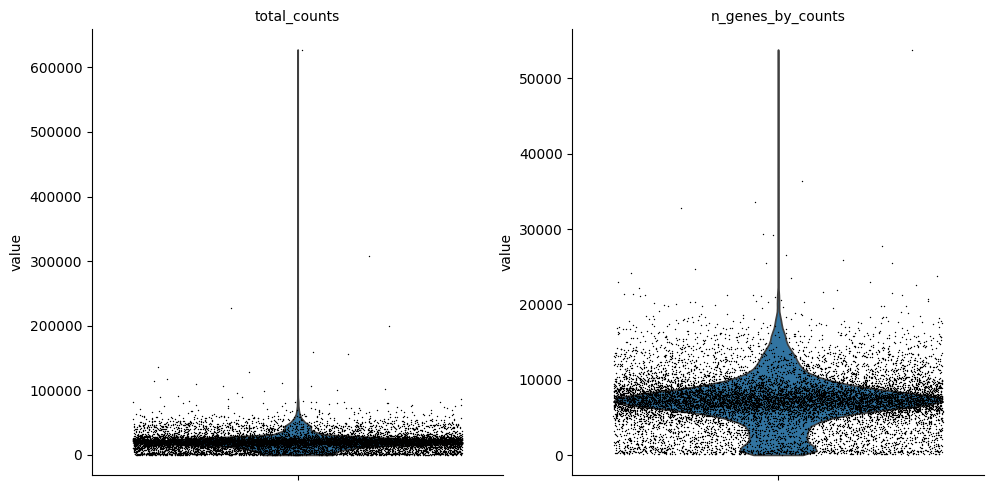

In [24]:
sc.pl.violin(atac, ["total_counts", "n_genes_by_counts"], jitter=0.4, multi_panel=True)

Filter peaks whose expression is not detected

In [25]:
mu.pp.filter_var(atac, "n_cells_by_counts", lambda x: x >= 10)
# This is analogous to
#   sc.pp.filter_genes(rna, min_cells=10)
# but does in-place filtering and avoids copying the object

Then we filter the cells

In [26]:
mu.pp.filter_obs(atac, "n_genes_by_counts", lambda x: (x >= 2000) & (x <= 15000))
# This is analogous to
#   sc.pp.filter_cells(atac, max_genes=15000)
#   sc.pp.filter_cells(atac, min_genes=2000)
# but does in-place filtering avoiding copying the object

mu.pp.filter_obs(atac, "total_counts", lambda x: (x >= 4000) & (x <= 40000))

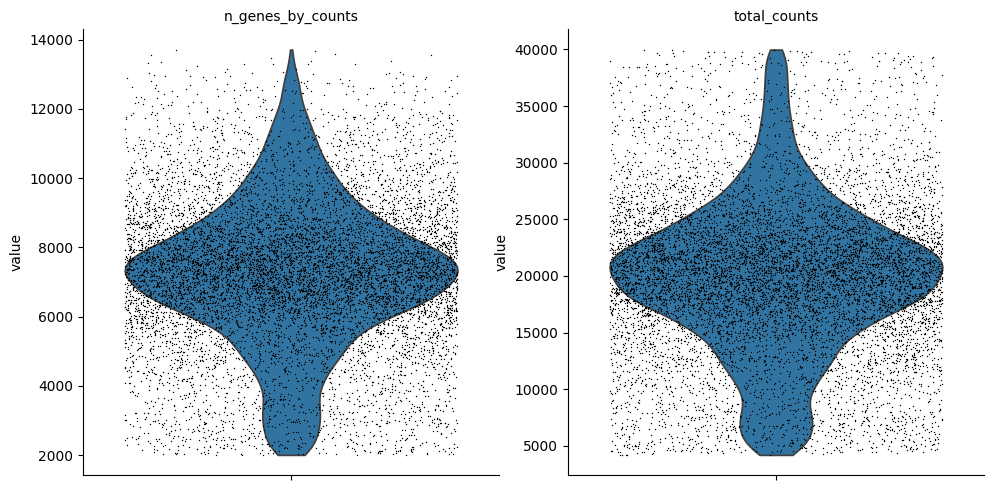

In [27]:
sc.pl.violin(atac, ["n_genes_by_counts", "total_counts"], jitter=0.4, multi_panel=True)

Muon also provides histograms which allows for a different view on the metrics